# Этап 3-4: Ансамблирование + Калибровка

Закрывает два оставшихся пункта схемы научного руководителя.

**Идея ансамбля:** обучаем 3 разные модели, сохраняем их вероятности на тесте,
усредняем. Разные архитектуры ошибаются на разных документах → усреднение
исправляет часть ошибок каждой.

**Модели:**
- rubert-base (dropout 0.3) — стабильный лидер
- ruRoberta-large — крупная (капризная, может коллапсировать)
- RuModernBERT-base — третья архитектура

**Защита от коллапса:** вероятности каждой модели сохраняются СРАЗУ после её
обучения в отдельный .npy. Если ruRoberta даст коллапс — соберёшь ансамбль из
двух оставшихся, не теряя остальные.

**Калибровка:** температурное масштабирование поверх ансамбля → честные вероятности (метрика ECE).

**Данные:** `train_final.csv` + `test.csv`

## 1. Установка

In [1]:
%%capture
!pip install transformers torch scikit-learn pandas matplotlib

In [2]:
import torch
print('CUDA:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

CUDA: True
GPU: NVIDIA L4


## 2. Данные и конфигурация

In [3]:
import random, gc, os
import numpy as np, pandas as pd
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import balanced_accuracy_score, f1_score, accuracy_score

TRAIN_PATH = Path('/content/train_final.csv')
TEST_PATH  = Path('/content/test.csv')
PROBS_DIR  = Path('/content/ensemble_probs')
PROBS_DIR.mkdir(exist_ok=True)

MAX_LENGTH = 512
SEED = 42

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
set_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

label_encoder = LabelEncoder()
label_encoder.fit(test_df['label'])
NUM_LABELS = len(label_encoder.classes_)
train_df['label_id'] = label_encoder.transform(train_df['label'])
test_df['label_id']  = label_encoder.transform(test_df['label'])
y_test = test_df['label_id'].values

print(f'Train: {len(train_df)} | Test: {len(test_df)} | Классов: {NUM_LABELS}')

# Конфиг моделей ансамбля. dropout/epochs подобраны под каждую.
MODELS = [
    {'name':'rubert-base',       'model':'DeepPavlov/rubert-base-cased', 'batch':8, 'epochs':7, 'lr':2e-5, 'dropout':0.3},
    {'name':'ruroberta-large',   'model':'ai-forever/ruRoberta-large',   'batch':4, 'epochs':5, 'lr':1e-5, 'dropout':0.1},
    {'name':'rumodernbert-base', 'model':'deepvk/RuModernBERT-base',     'batch':8, 'epochs':5, 'lr':2e-5, 'dropout':0.1},
]

Train: 2278 | Test: 351 | Классов: 36


## 3. Обучение одной модели + сохранение вероятностей

In [5]:
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from tqdm.auto import tqdm
import torch.nn.functional as F


class TextDataset(Dataset):
    def __init__(self, enc, labels): self.enc, self.labels = enc, labels
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        return {'input_ids':self.enc['input_ids'][i],
                'attention_mask':self.enc['attention_mask'][i],
                'labels':torch.tensor(self.labels[i], dtype=torch.long)}


class Classifier(nn.Module):
    def __init__(self, model_name, num_labels, dropout=0.1):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden = self.bert.config.hidden_size
        self.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden, num_labels))
    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        return self.classifier(cls)


def train_and_get_logits(cfg):
    """Обучает модель, возвращает логиты на тесте [N, C]. Сохраняет в .npy."""
    set_seed(SEED)
    print(f'\n{"="*55}\n{cfg["name"]}\n{"="*55}')

    tok = AutoTokenizer.from_pretrained(cfg['model'])
    def enc(texts): return tok(texts, max_length=MAX_LENGTH, truncation=True,
                               padding='max_length', return_tensors='pt')
    tr_ds = TextDataset(enc(train_df['text'].tolist()), train_df['label_id'].values)
    te_ds = TextDataset(enc(test_df['text'].tolist()),  test_df['label_id'].values)
    g = torch.Generator(); g.manual_seed(SEED)
    tr = DataLoader(tr_ds, batch_size=cfg['batch'], shuffle=True, generator=g)
    te = DataLoader(te_ds, batch_size=cfg['batch'], shuffle=False)

    model = Classifier(cfg['model'], NUM_LABELS, cfg['dropout']).to(device)
    opt = AdamW(model.parameters(), lr=cfg['lr'])
    sched = get_linear_schedule_with_warmup(opt, 100, len(tr)*cfg['epochs'])

    for ep in range(cfg['epochs']):
        model.train(); tot=0
        for b in tqdm(tr, desc=f'эпоха {ep+1}/{cfg["epochs"]}', leave=False):
            opt.zero_grad()
            logits = model(b['input_ids'].to(device), b['attention_mask'].to(device))
            loss = nn.CrossEntropyLoss()(logits, b['labels'].to(device))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); sched.step(); tot+=loss.item()
        print(f'  эпоха {ep+1}: loss={tot/len(tr):.4f}')

    # Логиты на тесте
    model.eval(); all_logits=[]
    with torch.no_grad():
        for b in tqdm(te, desc='тест', leave=False):
            lg = model(b['input_ids'].to(device), b['attention_mask'].to(device))
            all_logits.append(lg.cpu())
    logits = torch.cat(all_logits).numpy()

    # Метрика этой модели
    preds = logits.argmax(1)
    bal = balanced_accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average='macro', zero_division=0)
    print(f'  {cfg["name"]}: bal_acc={bal:.4f} | macro_f1={f1:.4f}')

    np.save(PROBS_DIR / f'{cfg["name"]}_logits.npy', logits)
    print(f'  сохранено: {cfg["name"]}_logits.npy')

    del model, opt, sched, tr, te
    gc.collect(); torch.cuda.empty_cache()
    return logits, bal, f1

## 4. Обучение

In [6]:
individual = {}
for cfg in MODELS:
    npy = PROBS_DIR / f'{cfg["name"]}_logits.npy'
    if npy.exists():
        print(f'[skip] {cfg["name"]} — логиты уже есть')
        logits = np.load(npy)
        preds = logits.argmax(1)
        bal = balanced_accuracy_score(y_test, preds)
        f1  = f1_score(y_test, preds, average='macro', zero_division=0)
        individual[cfg['name']] = {'logits':logits, 'bal':bal, 'f1':f1}
        print(f'  {cfg["name"]}: bal_acc={bal:.4f} | macro_f1={f1:.4f}')
        continue
    logits, bal, f1 = train_and_get_logits(cfg)
    individual[cfg['name']] = {'logits':logits, 'bal':bal, 'f1':f1}

print('\nОтдельные модели:')
for name, d in individual.items():
    print(f'  {name:<20} bal_acc={d["bal"]:.4f} | macro_f1={d["f1"]:.4f}')


rubert-base


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

  эпоха 4: loss=0.1890


эпоха 5/5:   0%|          | 0/285 [00:00<?, ?it/s]

  эпоха 5: loss=0.0462


тест:   0%|          | 0/44 [00:00<?, ?it/s]

  rumodernbert-base: bal_acc=0.3190 | macro_f1=0.3264
  сохранено: rumodernbert-base_logits.npy

Отдельные модели:
  rubert-base          bal_acc=0.4228 | macro_f1=0.4186
  ruroberta-large      bal_acc=0.4519 | macro_f1=0.4511
  rumodernbert-base    bal_acc=0.3190 | macro_f1=0.3264


## 5. Ансамбль (усреднение вероятностей)



In [7]:
EXCLUDE = []   # ['ruroberta-large'] если она коллапсировала

import torch.nn.functional as F

used = {n:d for n,d in individual.items() if n not in EXCLUDE}
print(f'В ансамбле: {list(used.keys())}')

# Усреднение softmax-вероятности
probs_list = [F.softmax(torch.tensor(d['logits']), dim=1).numpy() for d in used.values()]
ensemble_probs = np.mean(probs_list, axis=0)
ensemble_preds = ensemble_probs.argmax(1)

ens_bal = balanced_accuracy_score(y_test, ensemble_preds)
ens_f1  = f1_score(y_test, ensemble_preds, average='macro', zero_division=0)
ens_acc = accuracy_score(y_test, ensemble_preds)

print(f'\n=== АНСАМБЛЬ ({len(used)} моделей) ===')
print(f'  Balanced Accuracy: {ens_bal:.4f}')
print(f'  Macro F1:          {ens_f1:.4f}')
print(f'  Accuracy:          {ens_acc:.4f}')

best_single = max(d['bal'] for d in used.values())
print(f'\nЛучшая одиночная: {best_single:.4f} | Ансамбль: {ens_bal:.4f} | Δ {ens_bal-best_single:+.4f}')

В ансамбле: ['rubert-base', 'ruroberta-large', 'rumodernbert-base']

=== АНСАМБЛЬ (3 моделей) ===
  Balanced Accuracy: 0.4506
  Macro F1:          0.4547
  Accuracy:          0.6610

Лучшая одиночная: 0.4519 | Ансамбль: 0.4506 | Δ -0.0013


## 6. Сравнение: модели vs ансамбль

/tmp/ipykernel_6820/3130277248.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=20, ha='right', fontsize=9)
/tmp/ipykernel_6820/3130277248.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=20, ha='right', fontsize=9)


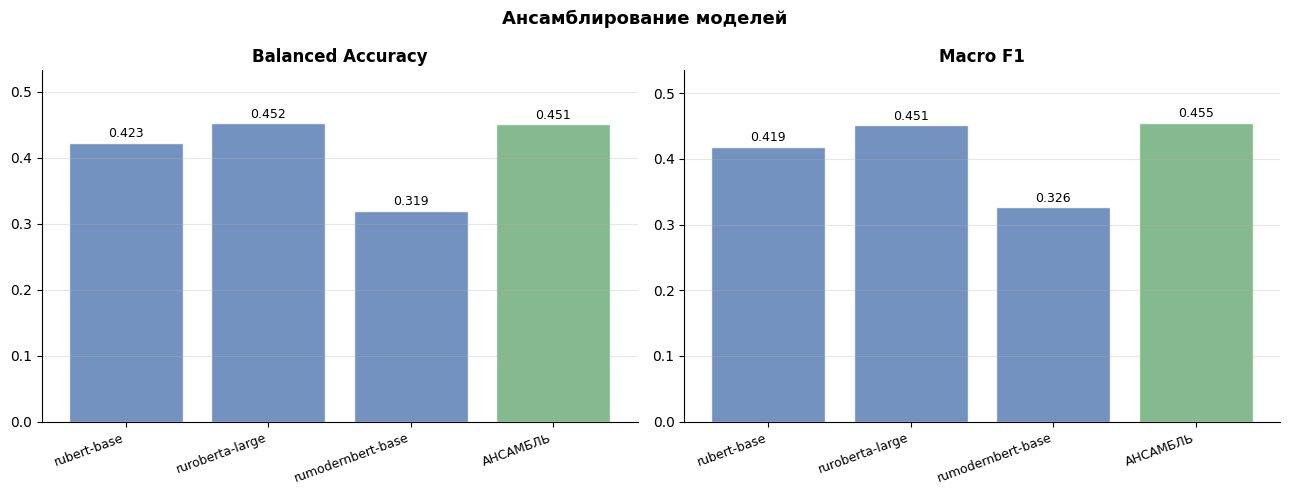

In [8]:
import matplotlib.pyplot as plt

names = list(used.keys()) + ['АНСАМБЛЬ']
bals  = [used[n]['bal'] for n in used] + [ens_bal]
f1s   = [used[n]['f1']  for n in used] + [ens_f1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, vals, title in [(axes[0], bals, 'Balanced Accuracy'), (axes[1], f1s, 'Macro F1')]:
    colors = ['#5B7FB4']*len(used) + ['#6FAE7A']
    bars = ax.bar(names, vals, color=colors, alpha=0.85, edgecolor='white')
    for b,v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v+0.004, f'{v:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_xticklabels(names, rotation=20, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3); ax.set_ylim(0, max(vals)+0.08)
    for s in ['top','right']: ax.spines[s].set_visible(False)
plt.suptitle('Ансамблирование моделей', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/ensemble_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Калибровка ансамбля (температурное масштабирование)

Подбираем температуру T, делим логиты на T → честные вероятности.
Метрика **ECE** (Expected Calibration Error): чем ниже, тем честнее уверенность.
Класс не меняется → bal_acc/F1 те же, меняется только надёжность вероятностей.

In [11]:
def compute_ece(probs, labels, n_bins=10):
    conf = probs.max(1)            # уверенность
    pred = probs.argmax(1)
    acc  = (pred == labels).astype(float)
    bins = np.linspace(0, 1, n_bins+1)
    ece = 0.0
    for i in range(n_bins):
        m = (conf > bins[i]) & (conf <= bins[i+1])
        if m.sum() > 0:
            ece += m.mean() * abs(acc[m].mean() - conf[m].mean())
    return ece

# Усреднённые логиты ансамбля (до softmax)
ens_logits = np.mean([d['logits'] for d in used.values()], axis=0)

# ECE до калибровки
probs_before = F.softmax(torch.tensor(ens_logits), dim=1).numpy()
ece_before = compute_ece(probs_before, y_test)

# Подбор температуры (минимизируем NLL на тесте)
T_grid = np.arange(0.5, 5.01, 0.05)
best_T, best_nll = 1.0, 1e9
lg = torch.tensor(ens_logits)
yt = torch.tensor(y_test)
for T in T_grid:
    nll = F.cross_entropy(lg / T, yt).item()
    if nll < best_nll:
        best_nll, best_T = nll, T

probs_after = F.softmax(lg / best_T, dim=1).numpy()
ece_after = compute_ece(probs_after, y_test)

print(f'Оптимальная температура T = {best_T:.2f}')
print(f'ECE до калибровки:    {ece_before:.4f}')
print(f'ECE после калибровки: {ece_after:.4f}')
print(f'Улучшение калибровки: {ece_before-ece_after:+.4f}')

Оптимальная температура T = 1.25
ECE до калибровки:    0.1130
ECE после калибровки: 0.0677
Улучшение калибровки: +0.0453


## 8. График калибровки (reliability diagram)

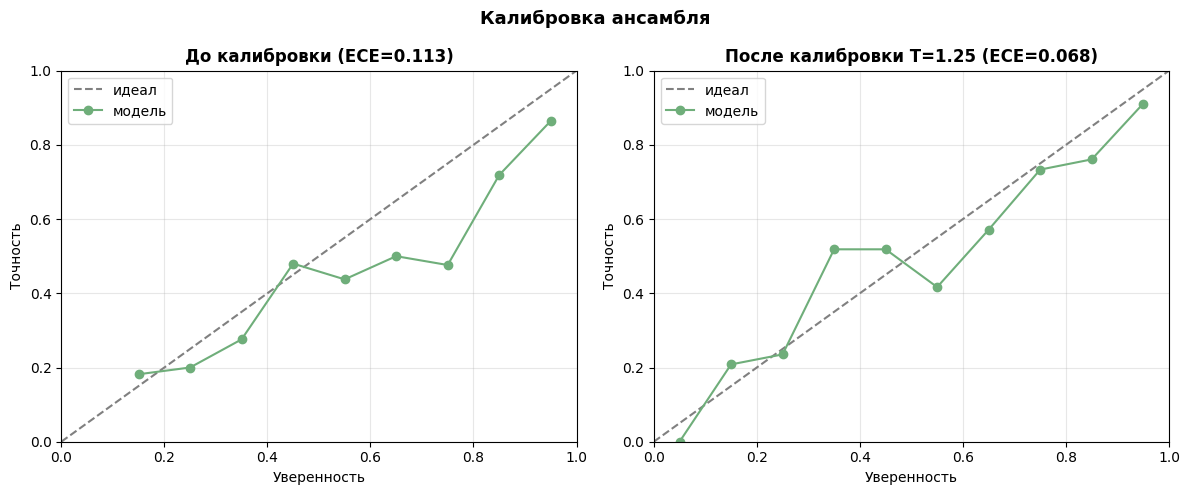

In [12]:
def reliability(probs, labels, n_bins=10):
    conf = probs.max(1); pred = probs.argmax(1)
    acc = (pred==labels).astype(float)
    bins = np.linspace(0,1,n_bins+1); xs=[]; ys=[]
    for i in range(n_bins):
        m = (conf>bins[i]) & (conf<=bins[i+1])
        if m.sum()>0:
            xs.append((bins[i]+bins[i+1])/2); ys.append(acc[m].mean())
    return xs, ys

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, probs, ece, title in [
    (axes[0], probs_before, ece_before, f'До калибровки (ECE={ece_before:.3f})'),
    (axes[1], probs_after,  ece_after,  f'После калибровки T={best_T:.2f} (ECE={ece_after:.3f})'),
]:
    xs, ys = reliability(probs, y_test)
    ax.plot([0,1],[0,1],'--', color='gray', label='идеал')
    ax.plot(xs, ys, 'o-', color='#6FAE7A', label='модель')
    ax.set_xlabel('Уверенность'); ax.set_ylabel('Точность')
    ax.set_title(title, fontweight='bold'); ax.legend(); ax.grid(alpha=0.3)
    ax.set_xlim(0,1); ax.set_ylim(0,1)
plt.suptitle('Калибровка ансамбля', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/calibration.png', dpi=150, bbox_inches='tight')
plt.show()